In [7]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import joblib


In [8]:
# =========================================
#  UNZIP DATASET FILE
# =========================================

from zipfile import ZipFile
import os

# Path to your uploaded ZIP file in Colab
zip_path = "/content/bank+marketing.zip"

# Directory to extract files into
extract_dir = "/content/"

# Extract the ZIP file
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ File successfully unzipped!")
print("📂 Extracted files:")
os.listdir(extract_dir)


✅ File successfully unzipped!
📂 Extracted files:


['.config',
 'drive',
 '__MACOSX',
 'bank.zip',
 'bank+marketing.zip',
 'bank-additional.zip',
 'bank-additional',
 'sample_data']

In [2]:
# =========================================
# 📂 VIEW CONTENTS OF A ZIP FILE
# =========================================

from zipfile import ZipFile

# Path to your uploaded zip file
zip_path = "/content/bank.zip"

# Open the ZIP file and list its contents
with ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

print("📦 Files inside the ZIP archive:")
for file in file_list:
    print(" -", file)


📦 Files inside the ZIP archive:
 - bank-full.csv
 - bank-names.txt
 - bank.csv


In [3]:
# =========================================
# 📂 VIEW CONTENTS OF A ZIP FILE
# =========================================

from zipfile import ZipFile

# Path to your uploaded zip file
zip_path = "/content/bank-additional.zip"

# Open the ZIP file and list its contents
with ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

print("📦 Files inside the ZIP archive:")
for file in file_list:
    print(" -", file)

📦 Files inside the ZIP archive:
 - bank-additional/
 - bank-additional/.DS_Store
 - __MACOSX/
 - __MACOSX/bank-additional/
 - __MACOSX/bank-additional/._.DS_Store
 - bank-additional/.Rhistory
 - bank-additional/bank-additional-full.csv
 - bank-additional/bank-additional-names.txt
 - bank-additional/bank-additional.csv
 - __MACOSX/._bank-additional


In [4]:
# =========================================
# 📂 VIEW CONTENTS OF A ZIP FILE
# =========================================

from zipfile import ZipFile

# Path to your uploaded zip file
zip_path = "/content/bank+marketing.zip"

# Open the ZIP file and list its contents
with ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

print("📦 Files inside the ZIP archive:")
for file in file_list:
    print(" -", file)

📦 Files inside the ZIP archive:
 - bank.zip
 - bank-additional.zip


In [5]:
# =========================================
#  UNZIP DATASET FILE
# =========================================

from zipfile import ZipFile
import os

# Path to your uploaded ZIP file in Colab
zip_path = "/content/bank-additional.zip"

# Directory to extract files into
extract_dir = "/content/"

# Extract the ZIP file
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ File successfully unzipped!")
print("📂 Extracted files:")
os.listdir(extract_dir)


✅ File successfully unzipped!
📂 Extracted files:


['.config',
 'drive',
 '__MACOSX',
 'bank.zip',
 'bank+marketing.zip',
 'bank-additional.zip',
 'bank-additional',
 'sample_data']

In [6]:
# =========================================
# 📂 VIEW CONTENTS OF A ZIP FILE
# =========================================

from zipfile import ZipFile

# Path to your uploaded zip file
zip_path = "/content/bank-additional.zip"

# Open the ZIP file and list its contents
with ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

print("📦 Files inside the ZIP archive:")
for file in file_list:
    print(" -", file)

📦 Files inside the ZIP archive:
 - bank-additional/
 - bank-additional/.DS_Store
 - __MACOSX/
 - __MACOSX/bank-additional/
 - __MACOSX/bank-additional/._.DS_Store
 - bank-additional/.Rhistory
 - bank-additional/bank-additional-full.csv
 - bank-additional/bank-additional-names.txt
 - bank-additional/bank-additional.csv
 - __MACOSX/._bank-additional


 Files inside the ZIP archive:
 - bank-full.csv
 - bank-names.txt
 - bank.csv
 - bank-additional/bank-additional-full.csv
 - bank-additional/bank-additional-names.txt
 - bank-additional/bank-additional.csv

Configuration and helper functions

In [14]:
# -------- CONFIG --------
DATA_PATH = "/content/bank-additional-full.csv"
RANDOM_STATE = 42
MODEL_OUT = "dt_bank_model.joblib"
# ------------------------

def load_data(path):
    """Load CSV file from UCI dataset (semicolon separated)."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found.")
    df = pd.read_csv(path, sep=';')
    return df

def basic_eda(df):
    print("=== Basic dataset info ===")
    print("Shape:", df.shape)
    print("\nTarget distribution (y):")
    print(df['y'].value_counts(dropna=False))
    print("\nMissing values per column:")
    print(df.isnull().sum())
    print("\nSample rows:")
    display(df.head())


Preprocessing and splitting

In [20]:
def preprocess_and_split(df):
    df = df.copy()
    df['y'] = df['y'].map({'no': 0, 'yes': 1})
    assert df['y'].isnull().sum() == 0, "Target contains unexpected values."

    X = df.drop(columns=['y'])
    y = df['y']

    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    print("\nCategorical columns:", categorical_cols)
    print("Numeric columns:", numeric_cols)

    preprocessor = ColumnTransformer(
        transformers=[
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ],
        remainder='passthrough'
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    return preprocessor, X_train, X_test, y_train, y_test


Model Building and Training

In [21]:
def build_and_train(preprocessor, X_train, y_train):
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

    pipe = Pipeline([
        ('pre', preprocessor),
        ('clf', clf)
    ])

    param_grid = {
        'clf__criterion': ['gini', 'entropy'],
        'clf__max_depth': [5, 8, 12, None],
        'clf__min_samples_split': [2, 5, 10],
        'clf__class_weight': [None, 'balanced']
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    print("\n=== Best Parameters ===")
    print(grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    return grid.best_estimator_, grid


Model Evaluation


In [22]:
def evaluate(model, X_test, y_test):
    print("\n=== Model Evaluation ===")
    y_pred = model.predict(X_test)

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

    return y_pred, y_proba


Dicision Tree Vizualisation


In [23]:
def plot_tree_from_model(trained_pipeline, max_display_depth=3):
    clf = trained_pipeline.named_steps['clf']
    pre = trained_pipeline.named_steps['pre']

    ohe = None
    cat_cols = []
    for name, transformer, cols in pre.transformers_:
        if name == 'ohe':
            ohe = transformer
            cat_cols = cols
            break

    numeric_cols = [c for c in pre.transformers_[-1][2]] if pre.transformers_[-1][0] == 'remainder' else []

    if ohe is not None:
        try:
            ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
        except Exception:
            ohe_feature_names = []
            for i, col in enumerate(cat_cols):
                cats = ohe.categories_[i]
                ohe_feature_names += [f"{col}_{c}" for c in cats]
    else:
        ohe_feature_names = []

    feature_names = ohe_feature_names + numeric_cols

    plt.figure(figsize=(20, 10))
    plot_tree(clf, max_depth=max_display_depth, feature_names=feature_names, class_names=["no", "yes"], filled=True, fontsize=8)
    plt.title("Decision Tree (top levels)")
    plt.show()


=== Basic dataset info ===
Shape: (41188, 21)

Target distribution (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Sample rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Best Parameters ===
{'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 12, 'clf__min_samples_split': 2}
Best CV F1: 0.5825655798146986

=== Model Evaluation ===
Accuracy: 0.8709638261714008
Precision: 0.4607329842931937
Recall: 0.853448275862069
F1 Score: 0.5984132980732905
ROC AUC: 0.8846230217227228

Confusion Matrix:
 [[6383  927]
 [ 136  792]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9791    0.8732    0.9231      7310
           1     0.4607    0.8534    0.5984       928

    accuracy                         0.8710      8238
   macro avg     0.7199    0.8633

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


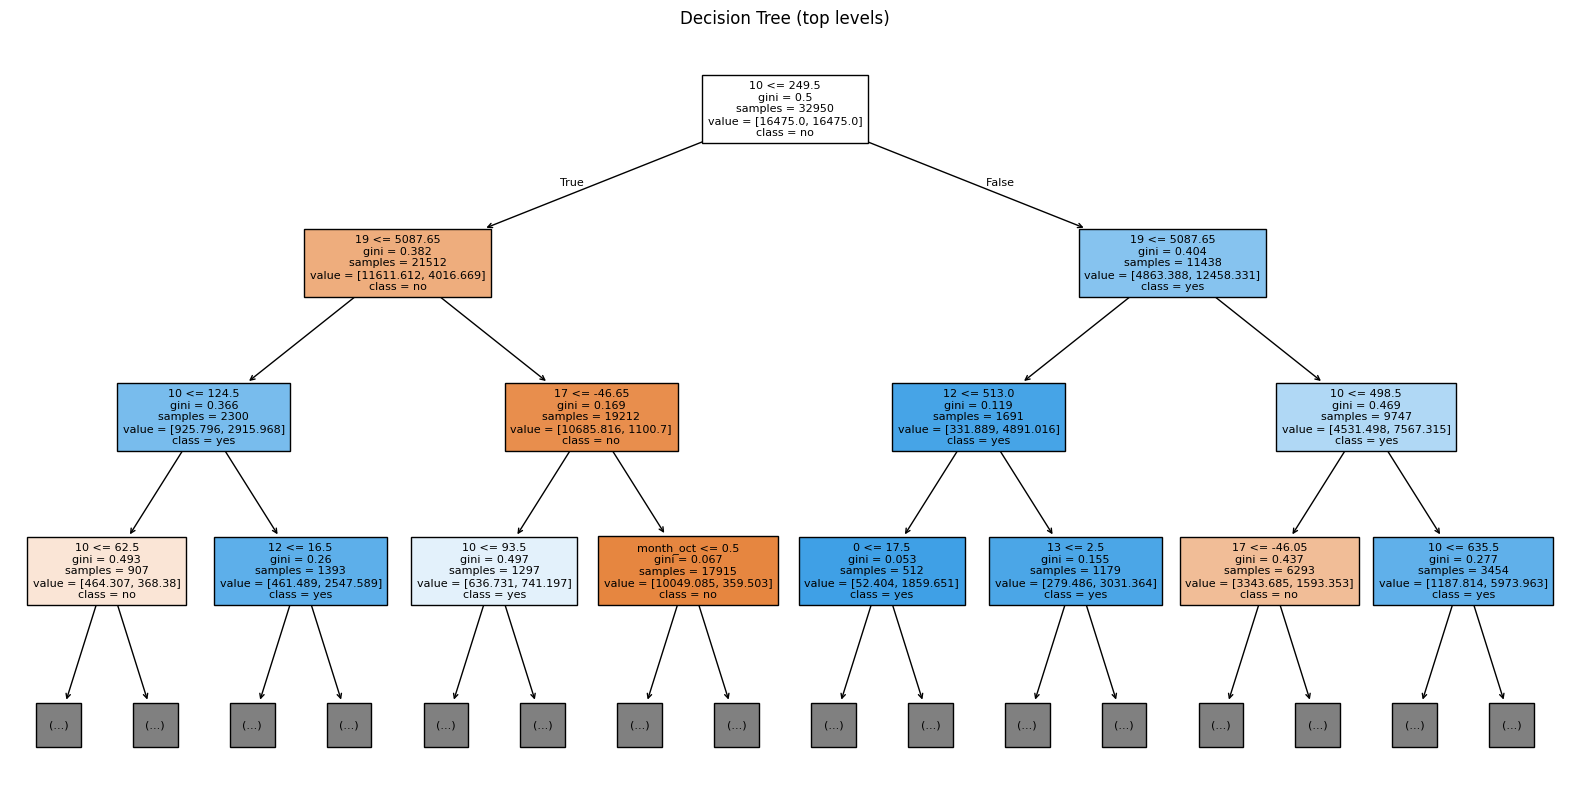

In [24]:
# === MAIN PIPELINE ===
df = load_data(DATA_PATH)
basic_eda(df)

preprocessor, X_train, X_test, y_train, y_test = preprocess_and_split(df)
best_model, grid_search = build_and_train(preprocessor, X_train, y_train)
y_pred, y_proba = evaluate(best_model, X_test, y_test)

# Save model
joblib.dump(best_model, MODEL_OUT)
print(f"\n✅ Model saved as: {MODEL_OUT}")

# Print summary tree (text form)
dt = best_model.named_steps['clf']
print("\n=== Text summary of decision tree ===")
print(export_text(dt, max_depth=3))

# Plot partial tree
plot_tree_from_model(best_model, max_display_depth=3)


In [27]:
# To test smaller datasets like 'bank-additional.csv' it is contained in my general Zip file
# simply re-run the same pipeline by changing the path:
DATA_PATH = "bank-additional.csv"  # or bank.csv / bank-full.csv

df_small = load_data(DATA_PATH)
basic_eda(df_small)

preprocessor, X_train, X_test, y_train, y_test = preprocess_and_split(df_small)
best_model, grid_search = build_and_train(preprocessor, X_train, y_train)
evaluate(best_model, X_test, y_test)


=== Basic dataset info ===
Shape: (4119, 21)

Target distribution (y):
y
no     3668
yes     451
Name: count, dtype: int64

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Sample rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no



Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Best Parameters ===
{'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 2}
Best CV F1: 0.5457323507527005

=== Model Evaluation ===
Accuracy: 0.8640776699029126
Precision: 0.4367816091954023
Recall: 0.8444444444444444
F1 Score: 0.5757575757575758
ROC AUC: 0.8867847411444142

Confusion Matrix:
 [[636  98]
 [ 14  76]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9785    0.8665    0.9191       734
           1     0.4368    0.8444    0.5758        90

    accuracy                         0.8641       824
   macro avg     0.7076    0.8555    

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
        0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 